# **Práctica 2.1: Análisis Exploratorio, Storytelling e Imputación Predictiva**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.experimental import enable_iterative_imputer  # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from google.colab import files

##1. Selección y Corrupción Determinista:

In [45]:
# 1. Configura de semilla
mi_boleta = 2021301999
np.random.seed(mi_boleta)

# Cargamos el dataset de Credit Card Fraud Detection
df = pd.read_csv('/content/creditcard_BankSim.csv')
# --- 1. CORRUPCIÓN DE DATOS (RETO 1) ---
# Inyectar 20% de nulos en variable continua (ej. 'amount')
nulos_cont_idx = np.random.choice(df.index, size=int(len(df)*0.20), replace=False)
df.loc[nulos_cont_idx, 'amount'] = np.nan

# Inyectar 15% de nulos en variable categórica (ej. 'age' o 'category')
nulos_cat_idx = np.random.choice(df.index, size=int(len(df)*0.15), replace=False)
df.loc[nulos_cat_idx, 'age'] = np.nan

# --- CÓDIGO PARA TU TABLA DE CORRUPCIÓN ---
conteo_nulos = df[['amount', 'age']].isnull().sum()

# 2. Calculamos el porcentaje real (para verificar que sea 20% y 15%)
porcentaje_nulos = (df[['amount', 'age']].isnull().mean()) * 100

# 3. Mostramos los resultados
print("--- DATOS PARA LA TABLA DE CORRUPCIÓN ---")
print(f"Variable 'amount' (Continua): {conteo_nulos['amount']} filas nulas ({porcentaje_nulos['amount']:.2f}%)")
print(f"Variable 'age' (Categórica): {conteo_nulos['age']} filas nulas ({porcentaje_nulos['age']:.2f}%)")


--- DATOS PARA LA TABLA DE CORRUPCIÓN ---
Variable 'amount' (Continua): 118928 filas nulas (20.00%)
Variable 'age' (Categórica): 89196 filas nulas (15.00%)


##2. Storytelling y SPLOM:

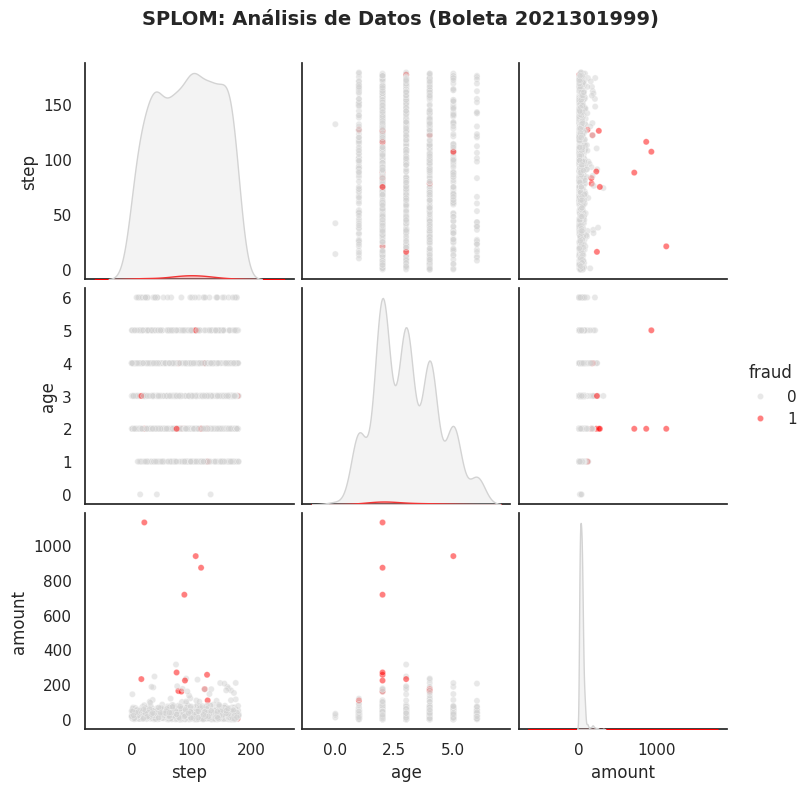

In [ ]:
# --- 2. PREPARACIÓN TÉCNICA (LIMPIEZA CRÍTICA) ---
# Limpiar 'age' (quitar comillas y convertir a número)
df['age'] = pd.to_numeric(df['age'].astype(str).str.replace("'", ""), errors='coerce')

#3. GENERACIÓN DEL SPLOM (SOLUCIÓN A CUADROS EN BLANCO) ---
# PASO CLAVE: Creamos un subset que NO tenga nulos para que Seaborn pueda dibujar los puntos
# Solo para la gráfica, eliminamos los NaN que inyectamos
df_plot = df[['step', 'age', 'amount', 'fraud']].dropna()

# Tomamos la muestra de los datos limpios
df_sample = df_plot.sample(n=1000, random_state=mi_boleta)

# Variables-> Variable Continua: log_amount (o amount)
# Variable Categórica : age,step
#variables = ['step', 'age', 'log_amount']
variables = ['step', 'age', 'amount']

# 14 sns.set_theme()
sns.set_theme(style="white")

# 15 sns.pairplot
# Storytelling: Resalta el fraude
g = sns.pairplot(df_sample, vars=variables, hue='fraud', diag_kind='kde', palette={0: "lightgray", 1: "red"}, plot_kws={'alpha': 0.5, 's': 20})

# 16 plt.show()
g.fig.suptitle(f'SPLOM: Análisis de Datos (Boleta {mi_boleta})', y=1.05, fontsize=14, fontweight='bold')
plt.show()

##3. Transformación de Distribuciones:

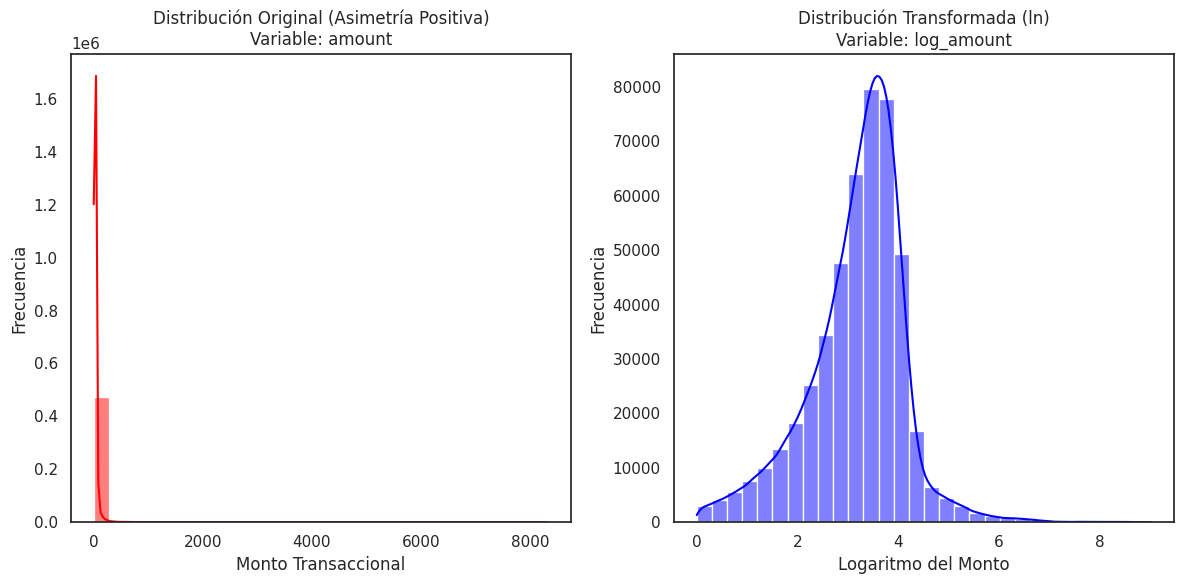

Asimetría (Skewness) original: 32.72
Asimetría (Skewness) transformada: -0.42


In [ ]:
# 1. Identificación y Transformación
# Usamos amount (continua) porque tiene fuerte asimetría positiva
# Aplicamos log1p para evitar errores con valores 0 (log(1+x))
df['log_amount'] = np.log1p(df['amount'])

# 2. Visualización de Superposición (Histogramas + KDE)
plt.figure(figsize=(12, 6))

# Subplot 1: Distribución Original (Asimétrica)
plt.subplot(1, 2, 1)
sns.histplot(df['amount'].dropna(), kde=True, color='red', bins=30)
plt.title('Distribución Original (Asimetría Positiva)\nVariable: amount')
plt.xlabel('Monto Transaccional')
plt.ylabel('Frecuencia')

# Subplot 2: Distribución Transformada (Normalizada)
plt.subplot(1, 2, 2)
sns.histplot(df['log_amount'].dropna(), kde=True, color='blue', bins=30)
plt.title('Distribución Transformada (ln)\nVariable: log_amount')
plt.xlabel('Logaritmo del Monto')
plt.ylabel('Frecuencia')

plt.tight_layout()

# Guardar la evidencia para el reporte
plt.savefig('transformacion_distribucion.png', dpi=300)
plt.show()

# 3. Demostración Estadística (Para tu tabla de resultados)
print(f"Asimetría (Skewness) original: {df['amount'].skew():.2f}")
print(f"Asimetría (Skewness) transformada: {df['log_amount'].skew():.2f}")

##4. Auditoría de Imputación Predictiva:

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(



--- AUDITORÍA DE IMPUTACIÓN ---
                  Método         (σ)  Pérdida de Varianza
0   Original (Con Nulos)  109.197850             0.000000
1           Media Global   97.669567            11.528283
2  Imputación Predictiva   97.872341            11.325509


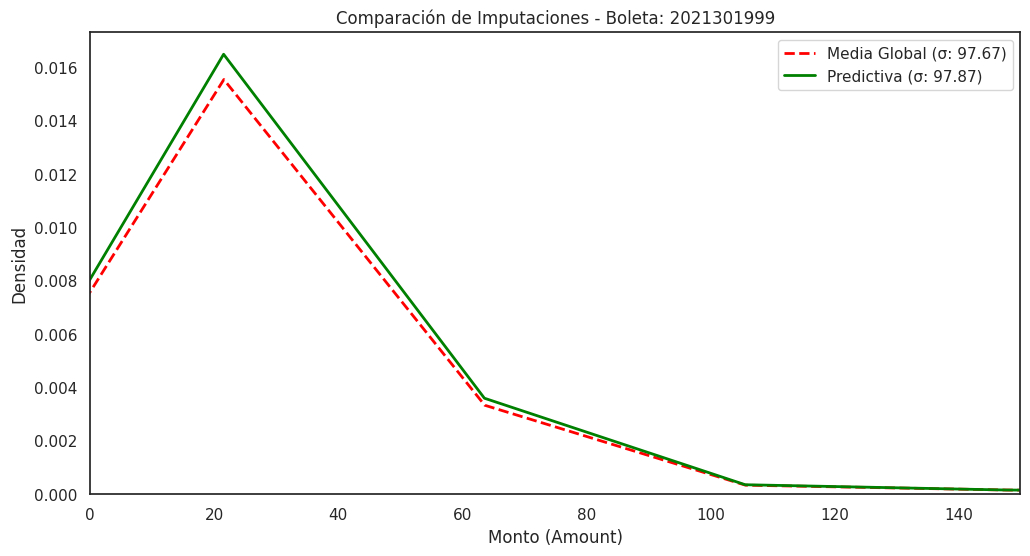

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Guardamos el sigma original (antes de la media) para comparar
sigma_original = df['amount'].std()

# ---. ESCENARIO A: IMPUTACIÓN POR MEDIA GLOBAL ---
df_media = df.copy()
df_media['amount'] = df_media['amount'].fillna(df_media['amount'].mean())
sigma_media = df_media['amount'].std()

# ---. ESCENARIO B: IMPUTACIÓN PREDICTIVA (MICE / Iterative) ---
# Seleccionamos las variables que se "ayudarán" entre sí
cols_imputar = ['step', 'age', 'amount']
df_pred = df.copy()

# Usamos RandomForestRegressor como estimador porque es más potente que una Regresión Lineal
# Esto cumple con "usar las demás variables para predecir" de forma simultánea
imputador = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=mi_boleta),
    max_iter=10,
    random_state=mi_boleta
)

# Aplicamos la imputación predictiva
df_pred[cols_imputar] = imputador.fit_transform(df[cols_imputar])
sigma_predictiva = df_pred['amount'].std()

# --- TABLA COMPARATIVA DE RESULTADOS ---
tabla_resultados = pd.DataFrame({
    'Método': ['Original (Con Nulos)', 'Media Global', 'Imputación Predictiva'],
    '(σ)': [sigma_original, sigma_media, sigma_predictiva],
    'Pérdida de Varianza': [0, sigma_original - sigma_media, sigma_original - sigma_predictiva]
})

print("\n--- AUDITORÍA DE IMPUTACIÓN ---")
print(tabla_resultados)

# --- 6. VISUALIZACIÓN PARA EL REPORTE ---
plt.figure(figsize=(12, 6))

# Graficamos ambas distribuciones
sns.kdeplot(df_media['amount'], label=f'Media Global (σ: {sigma_media:.2f})',
            color='red', lw=2, linestyle='--')
sns.kdeplot(df_pred['amount'], label=f'Predictiva (σ: {sigma_predictiva:.2f})',
            color='green', lw=2)

# Zoom en la zona de la media para ver el "pico"
plt.xlim(0, 150)
plt.title(f'Comparación de Imputaciones - Boleta: {mi_boleta}')
plt.xlabel('Monto (Amount)')
plt.ylabel('Densidad')
plt.legend()

plt.savefig('auditoria_final.png', dpi=300)
plt.show()